#### Using MNIST

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader

# 1. Prepare the data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

full_train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# 2. Split into Train and Validation
train_dataset, val_dataset = random_split(full_train_dataset, [0.8, 0.2])

# 3. Create DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [34]:
class SimpleCNN_MNIST(nn.Module):
    def __init__(self):
        super(SimpleCNN_MNIST, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self,x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        #print("Shape before flattening:", x.shape)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import os
from torch.utils.data import TensorDataset, DataLoader

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model, loss, optimizer
model = SimpleCNN_MNIST().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

num_epochs = 5

# Lists to store metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    # -------------------------
    # Training phase
    # -------------------------
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total
    epoch_train_acc = 100 * correct / total

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # -------------------------
    # Validation phase
    # -------------------------
    model.eval()
    val_running_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_running_loss / total_val
    epoch_val_acc = 100 * correct_val / total_val

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {epoch_train_loss:.4f} | "
          f"Train Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} | "
          f"Val Acc: {epoch_val_acc:.2f}%")

Epoch [1/5] | Train Loss: 0.1475 | Train Acc: 95.55% | Val Loss: 0.0563 | Val Acc: 98.36%
Epoch [2/5] | Train Loss: 0.0487 | Train Acc: 98.50% | Val Loss: 0.0621 | Val Acc: 98.16%
Epoch [3/5] | Train Loss: 0.0330 | Train Acc: 98.97% | Val Loss: 0.0447 | Val Acc: 98.62%
Epoch [4/5] | Train Loss: 0.0251 | Train Acc: 99.17% | Val Loss: 0.0379 | Val Acc: 98.92%
Epoch [5/5] | Train Loss: 0.0182 | Train Acc: 99.38% | Val Loss: 0.0420 | Val Acc: 98.87%


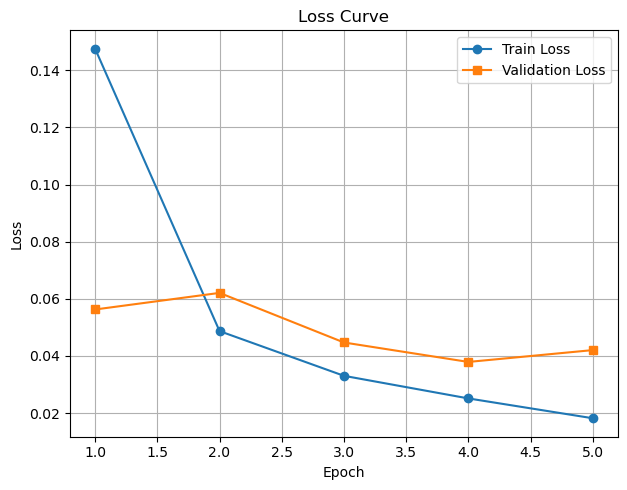

In [37]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, marker='o', label='Train Loss')
plt.plot(epochs, val_losses, marker='s', label='Validation Loss')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()

#### Using CIFAR-10

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split, DataLoader # <--- Don't forget to import these!

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),  # per-channel mean
                         (0.5, 0.5, 0.5))  # per-channel std
])

# 1. Load the FULL training dataset
full_trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)

# Extract the classes from the FULL dataset before splitting it
classes = full_trainset.classes  # ['airplane', 'automobile', 'bird', ...]

# 2. Split into Train and Validation using percentages (80% Train, 20% Val)
trainset, valset = random_split(full_trainset, [0.8, 0.2])

# 3. Create DataLoaders for Train and Validation
trainloader = DataLoader(
    trainset, batch_size=64, shuffle=True, num_workers=2
)
valloader = DataLoader(
    valset, batch_size=64, shuffle=False, num_workers=2
)

# 4. Load the Test dataset and create its DataLoader
testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)
testloader = DataLoader(
    testset, batch_size=64, shuffle=False, num_workers=2
)

print(f"Total training images: {len(full_trainset)}")
print(f"--> Sliced into: {len(trainset)} Train | {len(valset)} Validation")
print(f"Total testing images: {len(testset)}")

Using device: cuda
Total training images: 50000
--> Sliced into: 40000 Train | 10000 Validation
Total testing images: 10000


- Layer 1: Convolution
    - in_channels=3 (because it's an RGB image), out_channels=16 (16 filters)
    - padding=1 keeps the spatial size at 32x32

- Layer 2: Max Pooling
    - 2x2 window, stride of 2 (shrinks image dimensions by half)

- Layer 3: Convolution
    - Takes the 16 feature maps from the previous layer, creates 32 new ones

- Fully Connected (Dense) Layers for final classification
    - Math: Image starts at 32x32. 
    - After Pool 1 -> 16x16. After Pool 2 -> 8x8.
    - We have 32 channels * 8 * 8 spatial dimensions = 2048 total values.

In [5]:
class SimpleCNN_R(nn.Module):
    def __init__(self):
        super(SimpleCNN_R, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)

        self.drop = nn.Dropout(0.5)
        self.batch1 = nn.BatchNorm2d(16)
        self.batch2 = nn.BatchNorm2d(32)
        self.batch3 = nn.BatchNorm2d(64)

        self.fc1 = nn.Linear(64 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.batch1(self.conv1(x))))
        x = self.pool(self.relu(self.batch2(self.conv2(x))))
        x = self.pool(self.relu(self.batch3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.drop(x)
        x = self.fc2(x)
        return x


In [16]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)

        self.fc1 = nn.Linear(64 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x


- x = self.pool(self.relu(self.conv1(x)))
    - self.conv1(x): First, the raw images are passed through your first set of convolutional filters. The network scans the pixels and outputs feature maps (detecting low-level edges).

    - self.relu(...): The feature maps are immediately passed through a ReLU (Rectified Linear Unit) activation function. ReLU is incredibly simple: it looks at every single number in the feature map; if the number is positive, it keeps it. If the number is negative, it changes it to zero. This introduces "non-linearity," allowing the network to learn complex patterns instead of just straight lines.

    - self.pool(...): Finally, those activated feature maps are passed through the Max Pooling layer. This shrinks the spatial dimensions (width and height) by half, keeping only the strongest feature signals.

- x = x.view(x.size(0), -1)
    - The output from your third pooling layer is a 3D block of data (e.g., 64 channels, 4 pixels wide, 4 pixels high). But standard Fully Connected (Dense) layers only accept flat, 1D arrays of numbers.

- x = self.relu(self.fc1(x))
    - Now that the data is flattened, it flows into fc1 (Fully Connected Layer 1). This layer looks at all the extracted features simultaneously and learns which combinations of features correspond to which objects.

- x = self.fc2(x)
    - This is the final output layer. If you are doing CIFAR-10, fc2 will have exactly 10 output neurons.
    - In PyTorch, the standard loss function for classification (nn.CrossEntropyLoss) mathematically applies the Softmax operation internally. So, we just output the raw, un-activated scores (called "logits").

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# Model, loss, optimizer
model = SimpleCNN_R().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.003, weight_decay=1e-5)

num_epochs = 5

# Lists to store metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    # -------------------------
    # Training phase
    # -------------------------
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total
    epoch_train_acc = 100 * correct / total

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # -------------------------
    # Validation phase
    # -------------------------
    model.eval()
    val_running_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_running_loss / total_val
    epoch_val_acc = 100 * correct_val / total_val

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {epoch_train_loss:.4f} | "
          f"Train Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} | "
          f"Val Acc: {epoch_val_acc:.2f}%")

Epoch [1/5] | Train Loss: 1.5353 | Train Acc: 43.84% | Val Loss: 1.2773 | Val Acc: 52.40%
Epoch [2/5] | Train Loss: 1.1829 | Train Acc: 57.52% | Val Loss: 1.0335 | Val Acc: 63.74%
Epoch [3/5] | Train Loss: 1.0189 | Train Acc: 64.28% | Val Loss: 0.8828 | Val Acc: 68.93%
Epoch [4/5] | Train Loss: 0.9226 | Train Acc: 67.73% | Val Loss: 0.8439 | Val Acc: 70.49%
Epoch [5/5] | Train Loss: 0.8482 | Train Acc: 70.78% | Val Loss: 0.8128 | Val Acc: 72.30%


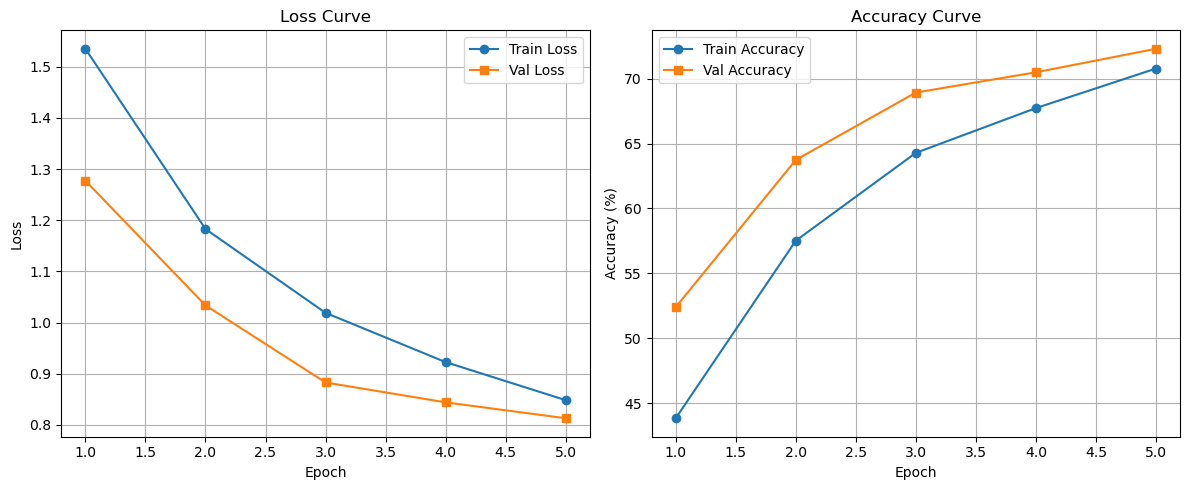

In [22]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, marker='o', label='Train Loss')
plt.plot(epochs, val_losses, marker='s', label='Val Loss')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, marker='o', label='Train Accuracy')
plt.plot(epochs, val_accuracies, marker='s', label='Val Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()